In [4]:
import sys
from pathlib import Path
import os

sys.path.append("..")

In [5]:
import importlib
import dataset.load_dataset as load_dataset

In [6]:
importlib.reload(load_dataset)
from dataset.load_dataset import SROIEDataset

# load image imports
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [7]:
# Detect if running in Google Colab
IN_COLAB = "google.colab" in str(get_ipython())
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DATASET_DIR = Path("/content/drive/MyDrive/datasets/my_dataset")
else:
    # "/Users/yourname/datasets/my_dataset" should be replaced with the actual path to your dataset on your local machine
    DATASET_DIR = Path("/Users/lua/.cache/kagglehub/datasets/dattrinh12/sroie-dataset")
print("Dataset path:", DATASET_DIR)

Dataset path: /Users/lua/.cache/kagglehub/datasets/dattrinh12/sroie-dataset


In [8]:
data_splits_path = DATASET_DIR / "versions/1"

In [9]:
sroie_dataset = SROIEDataset(dataset_dir=data_splits_path, debug=False)

[05/14/26 22:56:02] INFO     SROIEDataset - Images with all files taken for train: 681           ]8;id=1531582;file:///Users/lua/LoRA-DocExtract/colab_notebooks/../dataset/load_dataset.py\load_dataset.py]8;;\:]8;id=1531583;file:///Users/lua/LoRA-DocExtract/colab_notebooks/../dataset/load_dataset.py#42\42]8;;\

                    INFO     SROIEDataset - Images with all files taken for eval: 146            ]8;id=1531588;file:///Users/lua/LoRA-DocExtract/colab_notebooks/../dataset/load_dataset.py\load_dataset.py]8;;\:]8;id=1531589;file:///Users/lua/LoRA-DocExtract/colab_notebooks/../dataset/load_dataset.py#42\42]8;;\

                    INFO     SROIEDataset - Images with all files taken for test: 146            ]8;id=1531594;file:///Users/lua/LoRA-DocExtract/colab_notebooks/../dataset/load_dataset.py\load_dataset.py]8;;\:]8;id=1531595;file:///Users/lua/LoRA-DocExtract/colab_notebooks/../dataset/load_dataset.py#42\42]8;;\

In [10]:
sroie_dataset.train.head()

,doc_id,img_path,box_path,ent_path
0,X51005442327,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...
1,X51005568895,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...
2,X51005568855,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...
3,X51006441473,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...
4,X51005745190,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...,/Users/lua/.cache/kagglehub/datasets/dattrinh1...


In [11]:
sample = sroie_dataset.train.iloc[100]
sample

doc_id                                           X51007339126
img_path    /Users/lua/.cache/kagglehub/datasets/dattrinh1...
box_path    /Users/lua/.cache/kagglehub/datasets/dattrinh1...
ent_path    /Users/lua/.cache/kagglehub/datasets/dattrinh1...
Name: 100, dtype: str

In [13]:
sample["img_path"]

'/Users/lua/.cache/kagglehub/datasets/dattrinh12/sroie-dataset/versions/1/train/img/X51007339126.jpg'

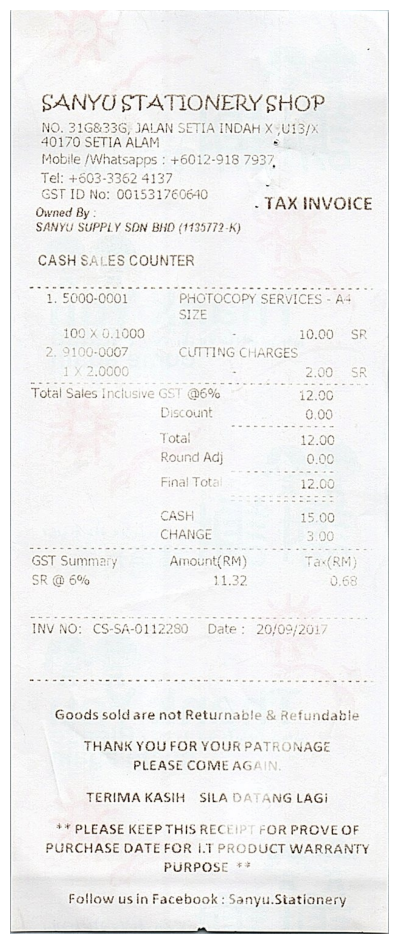

In [14]:
image = Image.open(sample["img_path"])
plt.figure(figsize=(12, 12))
plt.imshow(image)
plt.axis("off");

In [15]:
def read_box_file(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split(",")
            coords = list(map(int, parts[:8]))
            text = ",".join(parts[8:])
            rows.append({
                "x1": coords[0],
                "y1": coords[1],
                "x2": coords[2],
                "y2": coords[3],
                "x3": coords[4],
                "y3": coords[5],
                "x4": coords[6],
                "y4": coords[7],
                "text": text
            })
    return pd.DataFrame(rows)

def draw_boxes(ocr_df: pd.DataFrame, image: Image.Image):
    fig, ax = plt.subplots(figsize=(14, 14))
    ax.imshow(image)
    for _, row in ocr_df.iterrows():
        x = row["x1"]
        y = row["y1"]
        width = row["x2"] - row["x1"]
        height = row["y4"] - row["y1"]
        rect = patches.Rectangle(
            (x, y),
            width,
            height,
            linewidth=1,
            edgecolor="red",
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            x,
            y - 2,
            row["text"][:15],
            fontsize=6,
            color="blue"
        )
    plt.axis("off")
    plt.show()

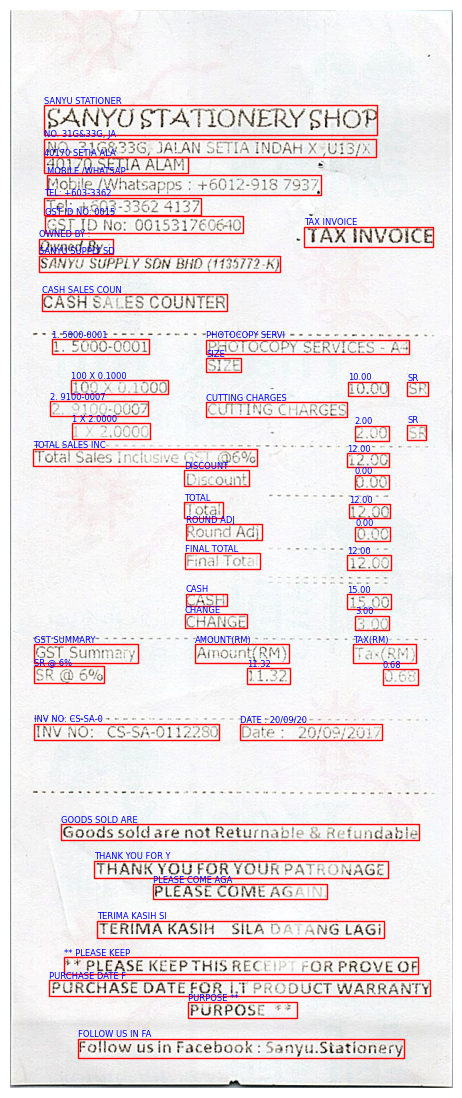

In [16]:
ocr_df = read_box_file(sample["box_path"])
#ocr_df.head()
draw_boxes(ocr_df, image)

In [17]:
with open(sample["ent_path"], "r", encoding="utf-8") as f:
    labels = f.read()

print(labels)

{
    "company": "SANYU STATIONERY SHOP",
    "date": "20/09/2017",
    "address": "NO. 31G&33G, JALAN SETIA INDAH X ,U13/X 40170 SETIA ALAM",
    "total": "12.00"
}
